# Preprocessing

**Dataset:** Mental Health and Lifestyle Habits (2019–2024)  
**Source:** https://www.kaggle.com/datasets/atharvasoundankar/mental-health-and-lifestyle-habits-2019-2024

---
## Content
1. Dataset Introduction
2. Variables Description
3. Data Preprocessing Steps
   - Load data
   - Meaning, check data type
   - Missing Values
   - Duplicates
   - Outliers
   - Categorical Encoding
   - Standardization / Normalization
4. Export Cleaned Dataset

## 0. Environment

In [7]:
# Install kagglehub to download dataset directly
!pip install kagglehub -q

In [8]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from google.colab import userdata
import warnings
warnings.filterwarnings('ignore')

pat_token = userdata.get('PAT')

if not os.path.exists("/content/114-2-CE5033-Final-Project"):
    !git clone https://{pat_token}@github.com/1syuju/114-2-CE5033-Final-Project /content/114-2-CE5033-Final-Project

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## 1. Dataset Introduction

**Mental Health and Lifestyle Habits (2019–2024)** is a dataset that records the relationship between lifestyle habits and mental health, with data collected from 2019 to 2024.

- **Purpose**: To explore how lifestyle habits such as sleep hours, exercise volume, and social media usage affect stress, anxiety, and depression indices.
- **Data Source**: Kaggle (public dataset)
- **Data Scale**: ≥ 1,500 records, ≥ 10 variables (meets course requirements)
- **Application Scenarios**: Mental health prediction, lifestyle improvement suggestions, public health analysis

In [9]:
# Load dataset from the GitHub repository
import pandas as pd
import os

repo_path = '/content/114-2-CE5033-Final-Project'
data_file_path = os.path.join(repo_path, 'data', 'Mental_Health_Lifestyle_Dataset.csv')

if os.path.exists(data_file_path):
    df_raw = pd.read_csv(data_file_path)
    print(f'Dataset loaded successfully from GitHub: {data_file_path}')
    print(f'Data shape: {df_raw.shape}')

# Display the first few rows of the loaded DataFrame
display(df_raw.head())

Dataset loaded successfully from GitHub: /content/114-2-CE5033-Final-Project/data/Mental_Health_Lifestyle_Dataset.csv
Data shape: (3000, 12)


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


---
## 2. Variables Description

Including columns in dataset, data types, and meanings

In [10]:
print('=' * 60)
print('Basic Info')
print('=' * 60)
df_raw.info()

Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      3000 non-null   object 
 1   Age                          3000 non-null   int64  
 2   Gender                       3000 non-null   object 
 3   Exercise Level               3000 non-null   object 
 4   Diet Type                    3000 non-null   object 
 5   Sleep Hours                  3000 non-null   float64
 6   Stress Level                 3000 non-null   object 
 7   Mental Health Condition      2405 non-null   object 
 8   Work Hours per Week          3000 non-null   int64  
 9   Screen Time per Day (Hours)  3000 non-null   float64
 10  Social Interaction Score     3000 non-null   float64
 11  Happiness Score              3000 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 281.4+ KB


In [11]:
col_summary = pd.DataFrame({
    'Column': df_raw.columns,
    'Dtype': df_raw.dtypes.values,
    'Non-Null Count': df_raw.notnull().sum().values,
    'Null Count': df_raw.isnull().sum().values,
    'Unique Values': df_raw.nunique().values,
    'Sample Values': [str(df_raw[c].dropna().unique()[:3].tolist()) for c in df_raw.columns]
})
print('\nColumn Summary：')
print(col_summary.to_string(index=False))


Column Summary：
                     Column   Dtype  Non-Null Count  Null Count  Unique Values                       Sample Values
                    Country  object            3000           0              7    ['Brazil', 'Australia', 'Japan']
                        Age   int64            3000           0             47                        [48, 31, 37]
                     Gender  object            3000           0              3         ['Male', 'Female', 'Other']
             Exercise Level  object            3000           0              3         ['Low', 'Moderate', 'High']
                  Diet Type  object            3000           0              5 ['Vegetarian', 'Vegan', 'Balanced']
                Sleep Hours float64            3000           0             93                     [6.3, 4.9, 7.2]
               Stress Level  object            3000           0              3         ['Low', 'High', 'Moderate']
    Mental Health Condition  object            2405         595

In [12]:
print('\nDescriptive Statistics：')
df_raw.describe().round(3)


Descriptive Statistics：


,Age,Sleep Hours,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
count,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000
mean,41.230,6.476,39.466,5.090,5.470,5.395
std,13.428,1.500,11.451,1.747,2.564,2.558
min,18.000,1.400,20.000,2.000,1.000,1.000
25%,30.000,5.500,30.000,3.600,3.300,3.200
50%,41.000,6.500,39.000,5.100,5.500,5.400
75%,53.000,7.500,50.000,6.600,7.600,7.500
max,64.000,11.300,59.000,8.000,10.000,10.000


In [13]:
cat_cols = df_raw.select_dtypes(include=['object', 'category']).columns
print(f'categories：{list(cat_cols)}\n')
for col in cat_cols:
    print(f'--- {col} ---')
    print(df_raw[col].value_counts())
    print()

categories：['Country', 'Gender', 'Exercise Level', 'Diet Type', 'Stress Level', 'Mental Health Condition']

--- Country ---
Country
USA          446
Japan        439
Australia    434
India        434
Canada       428
Brazil       415
Germany      404
Name: count, dtype: int64

--- Gender ---
Gender
Female    1024
Other      996
Male       980
Name: count, dtype: int64

--- Exercise Level ---
Exercise Level
Low         1033
Moderate     998
High         969
Name: count, dtype: int64

--- Diet Type ---
Diet Type
Junk Food     637
Balanced      625
Vegetarian    592
Vegan         573
Keto          573
Name: count, dtype: int64

--- Stress Level ---
Stress Level
Low         1008
High        1002
Moderate     990
Name: count, dtype: int64

--- Mental Health Condition ---
Mental Health Condition
Anxiety       628
PTSD          624
Depression    580
Bipolar       573
Name: count, dtype: int64



---
## 3. Data Preprocessing Steps

### 3.1 Missing Values

In [14]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) == 0:
    print('no missing value')
else:
    print(f'{len(missing_df)} missing values in total：')
    print(missing_df)

1 missing values in total：
                         Missing Count  Missing %
Mental Health Condition            595      19.83


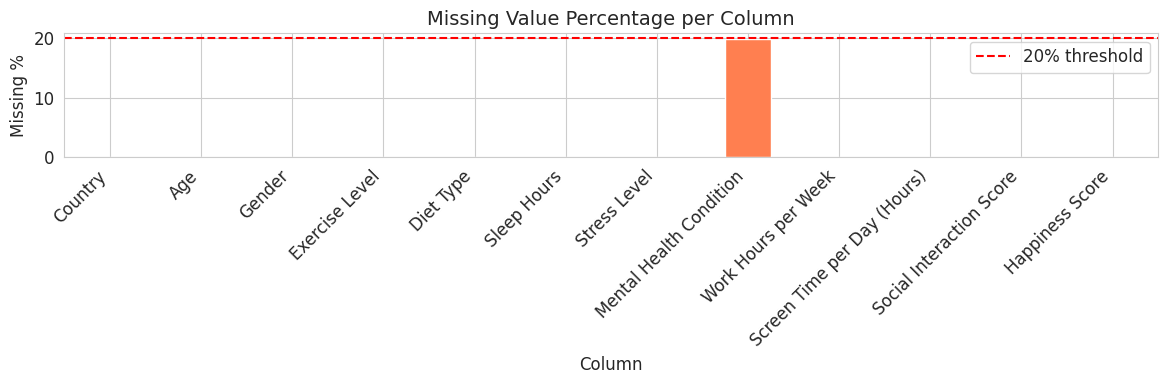

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
missing_pct_all = (df_raw.isnull().sum() / len(df_raw) * 100)
missing_pct_all.plot(kind='bar', color='coral', ax=ax)
ax.set_title('Missing Value Percentage per Column', fontsize=14)
ax.set_xlabel('Column')
ax.set_ylabel('Missing %')
ax.axhline(y=20, color='red', linestyle='--', label='20% threshold')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# preserve original data
df = df_raw.copy()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# use ME to fill val
for col in num_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'[Numeric] {col}: {n_missing} missing → ME {median_val:.2f}')

# use Mode to fill cat
for col in cat_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'[Categorical] {col}: {n_missing} missing → Mode "{mode_val}"')

print(f'\ntotal：{df.isnull().sum().sum()}')

[Categorical] Mental Health Condition: 595 missing → Mode "Anxiety"

total：0


### 3.2 Duplicate Rows

In [17]:
n_dup = df.duplicated().sum()
print(f'number of duplicates：{n_dup} / {len(df)} ({n_dup/len(df)*100:.2f}%)')

if n_dup > 0:
    print('\ne.g.：')
    print(df[df.duplicated()].head())
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'\nAfter removing duplicates, {len(df)} remain')
else:
    print('no dup')

number of duplicates：0 / 3000 (0.00%)
no dup


### 3.3 Outlier Detection

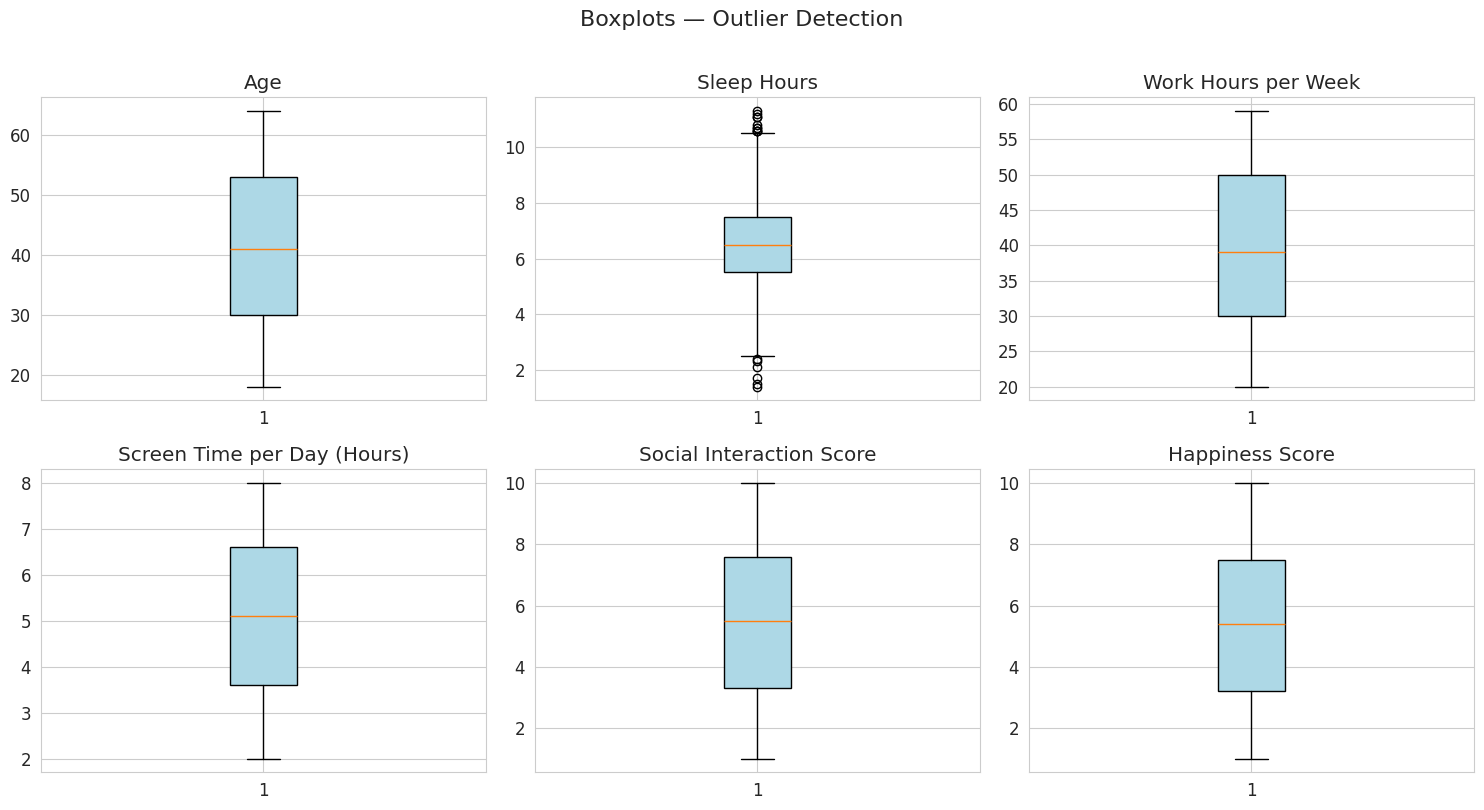

In [18]:
# Boxplot
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Outlier Detection', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# IQR
print('IQR 法異常值統計：')
print(f'{"Column":<30} {"Outliers":>10} {"Outlier %":>10}')
print('-' * 52)
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                             'lower': lower, 'upper': upper, 'n_outliers': n_out}
    print(f'{col:<30} {n_out:>10} {pct:>9.2f}%')

IQR 法異常值統計：
Column                           Outliers  Outlier %
----------------------------------------------------
Age                                     0      0.00%
Sleep Hours                            16      0.53%
Work Hours per Week                     0      0.00%
Screen Time per Day (Hours)             0      0.00%
Social Interaction Score                0      0.00%
Happiness Score                         0      0.00%


In [20]:
# Winsorization
df_clean = df.copy()
for col in num_cols:
    lower = outlier_summary[col]['lower']
    upper = outlier_summary[col]['upper']
    n_before = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    if n_before > 0:
        print(f'{col}: Clipped {n_before} outliers → [{lower:.2f}, {upper:.2f}]')

print(f'\n Winsorization done, remain：{len(df_clean)}')

Sleep Hours: Clipped 16 outliers → [2.50, 10.50]

 Winsorization done, remain：3000


### 3.4 Categorical Encoding

In [21]:
# 3.4 Label Encoding & One-Hot Encoding
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'category：{cat_cols}\n')

df_encoded = df_clean.copy()
le = LabelEncoder()

# binary → Label Encoding
binary_cols = [c for c in cat_cols if df_clean[c].nunique() == 2]
# >=3 → One-Hot Encoding
multi_cols  = [c for c in cat_cols if df_clean[c].nunique() > 2]

print(f'Binary columns (Label Encoding): {binary_cols}')
for col in binary_cols:
    df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col].astype(str))
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'\nMulti-category columns (One-Hot Encoding): {multi_cols}')
if multi_cols:
    df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=False)
    print(f'  After One-Hot encoding, add：{df_encoded.shape[1] - df_clean.shape[1]}')

print(f'\ndim：{df_encoded.shape}')

category：['Country', 'Gender', 'Exercise Level', 'Diet Type', 'Stress Level', 'Mental Health Condition']

Binary columns (Label Encoding): []

Multi-category columns (One-Hot Encoding): ['Country', 'Gender', 'Exercise Level', 'Diet Type', 'Stress Level', 'Mental Health Condition']
  After One-Hot encoding, add：19

dim：(3000, 31)


### 3.5 Standardization & Normalization

In [22]:
# 3.5 標準化
num_cols_final = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f'Standardization & Normalization：{num_cols_final}\n')

# Z-score Standardization
scaler_std = StandardScaler()
df_standardized = df_clean.copy()
df_standardized[num_cols_final] = scaler_std.fit_transform(df_clean[num_cols_final])

# Min-Max Normalization
scaler_mm = MinMaxScaler()
df_normalized = df_clean.copy()
df_normalized[num_cols_final] = scaler_mm.fit_transform(df_clean[num_cols_final])

print('Z-score Standardization：')
print(df_standardized[num_cols_final[:3]].describe().round(3))

Standardization & Normalization：['Age', 'Sleep Hours', 'Work Hours per Week', 'Screen Time per Day (Hours)', 'Social Interaction Score', 'Happiness Score']

Z-score Standardization：
            Age  Sleep Hours  Work Hours per Week
count  3000.000     3000.000             3000.000
mean      0.000        0.000                0.000
std       1.000        1.000                1.000
min      -1.730       -2.664               -1.700
25%      -0.836       -0.654               -0.827
50%      -0.017        0.016               -0.041
75%       0.877        0.686                0.920
max       1.696        2.696                1.706


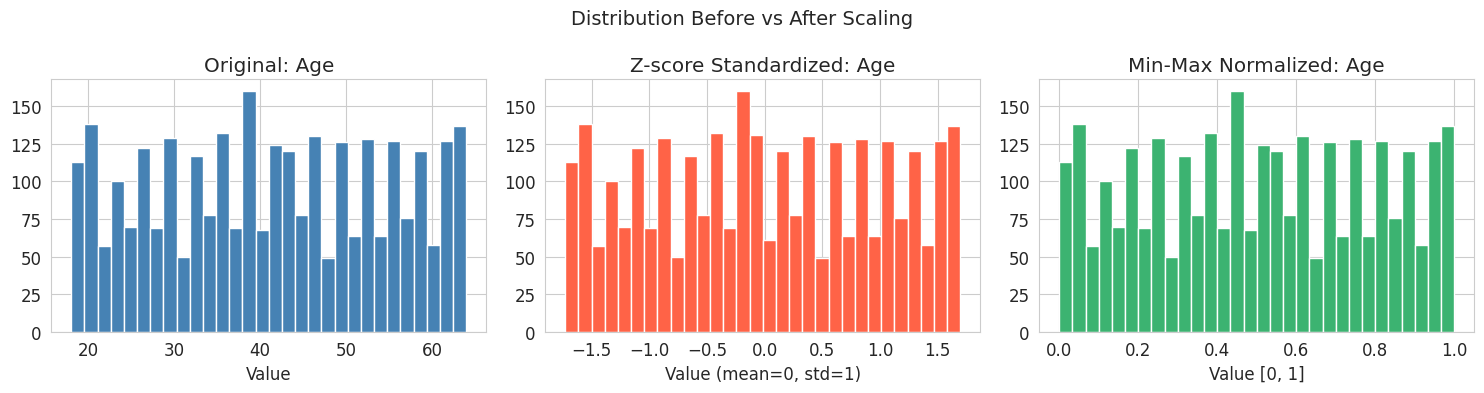

In [23]:
demo_col = num_cols_final[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_clean[demo_col], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f'Original: {demo_col}')
axes[0].set_xlabel('Value')

axes[1].hist(df_standardized[demo_col], bins=30, color='tomato', edgecolor='white')
axes[1].set_title(f'Z-score Standardized: {demo_col}')
axes[1].set_xlabel('Value (mean=0, std=1)')

axes[2].hist(df_normalized[demo_col], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title(f'Min-Max Normalized: {demo_col}')
axes[2].set_xlabel('Value [0, 1]')

plt.suptitle('Distribution Before vs After Scaling', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Data Quality Summary & Preprocessing Review

In [24]:
# 4.1 Comparison Before & After Preprocessing
print('=' * 55)
print('  Data Preprocessing Comparison (Data Quality Summary)')
print('=' * 55)
print(f'{'Item':<25} {'Before':>12} {'After':>12}')
print('-' * 55)
print(f'{'Number of Rows':<25} {df_raw.shape[0]:>12} {df_clean.shape[0]:>12}')
print(f'{'Number of Columns':<25} {df_raw.shape[1]:>12} {df_clean.shape[1]:>12}')
print(f'{'Total Missing Values':<25} {df_raw.isnull().sum().sum():>12} {df_clean.isnull().sum().sum():>12}')
print(f'{'Number of Duplicates':<25} {df_raw.duplicated().sum():>12} {df_clean.duplicated().sum():>12}')
print('=' * 55)
print()
print('Summary of Processing Steps:')
print('  1. Missing Values → Numeric columns imputed with median; Categorical columns with mode')
print('  2. Duplicates → Duplicate rows removed')
print('  3. Outliers → Detected by IQR method, Winsorization used to clip values to bounds')
print('  4. Categorical Encoding → Binary columns Label Encoded; Multi-category One-Hot Encoded')
print('  5. Numerical Standardization → Both Z-score & Min-Max versions retained')

  Data Preprocessing Comparison (Data Quality Summary)
Item                            Before        After
-------------------------------------------------------
Number of Rows                    3000         3000
Number of Columns                   12           12
Total Missing Values               595            0
Number of Duplicates                 0            0

Summary of Processing Steps:
  1. Missing Values → Numeric columns imputed with median; Categorical columns with mode
  2. Duplicates → Duplicate rows removed
  3. Outliers → Detected by IQR method, Winsorization used to clip values to bounds
  4. Categorical Encoding → Binary columns Label Encoded; Multi-category One-Hot Encoded
  5. Numerical Standardization → Both Z-score & Min-Max versions retained


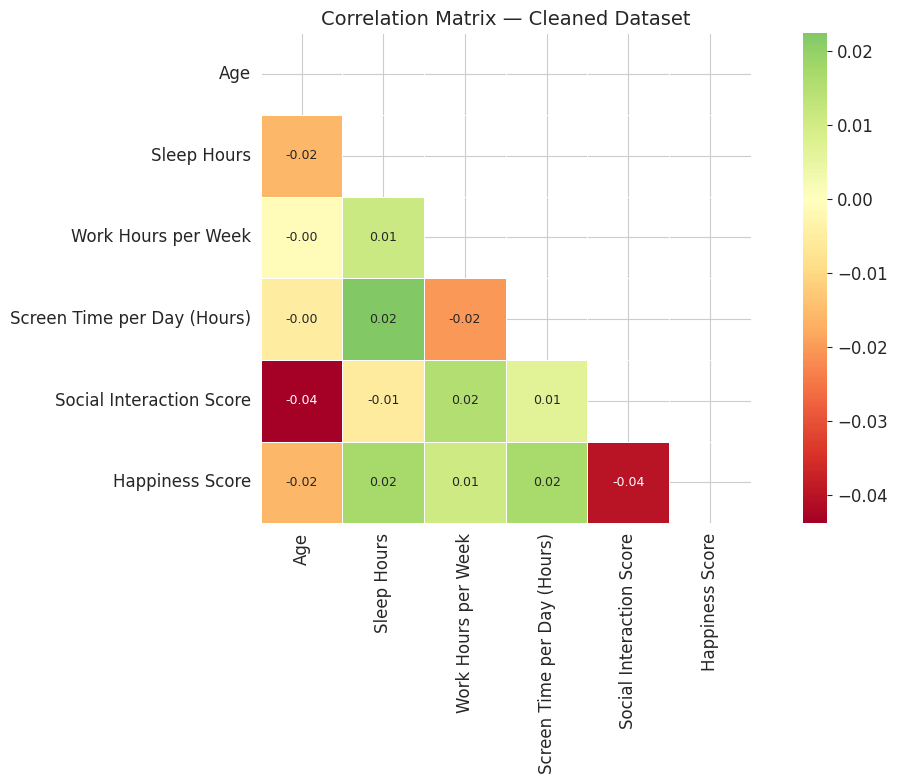

In [25]:
# 4.2 Heatmap
num_cols_final = df_clean.select_dtypes(include=[np.number]).columns
corr = df_clean[num_cols_final].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0,
            linewidths=0.5, square=True,
            annot_kws={'size': 9})
plt.title('Correlation Matrix — Cleaned Dataset', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Cleaned Dataset

In [26]:
df_clean.to_csv('cleaned_data.csv', index=False)
df_standardized.to_csv('cleaned_data_std.csv', index=False)

print('Exported the following files:')
print(' cleaned_data.csv     — Cleaned raw-scale data (for EDA & visualization)')
print(' cleaned_data_std.csv — Z-score standardized version (for ML model use)')
print(f'\nFinal data dimensions: {df_clean.shape}')
df_clean.head()

Exported the following files:
 cleaned_data.csv     — Cleaned raw-scale data (for EDA & visualization)
 cleaned_data_std.csv — Z-score standardized version (for ML model use)

Final data dimensions: (3000, 12)


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,Anxiety,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,Anxiety,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


# Exploratory Data Analysis (EDA)
---
## Content

1. EDA Overview

2. Descriptive Statistics

3. Distribution of Key Variables
   - Happiness Score
   - Sleep Hours
   - Screen Time per Day

4. Group Comparison
   - Stress Level and Happiness Score
   - Exercise Level and Happiness Score
   - Diet Type and Happiness Score

5. Correlation Analysis
   - Correlation Heatmap
   - Scatter Plot Analysis

6. EDA Summary

## 1. EDA Overview

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("cleaned_data.csv")

# Basic information
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst five rows:")
display(df.head())

Dataset shape: (3000, 12)

Column names:
Index(['Country', 'Age', 'Gender', 'Exercise Level', 'Diet Type',
       'Sleep Hours', 'Stress Level', 'Mental Health Condition',
       'Work Hours per Week', 'Screen Time per Day (Hours)',
       'Social Interaction Score', 'Happiness Score'],
      dtype='object')

Data types:
Country                         object
Age                              int64
Gender                          object
Exercise Level                  object
Diet Type                       object
Sleep Hours                    float64
Stress Level                    object
Mental Health Condition         object
Work Hours per Week              int64
Screen Time per Day (Hours)    float64
Social Interaction Score       float64
Happiness Score                float64
dtype: object

Missing values:
Country                        0
Age                            0
Gender                         0
Exercise Level                 0
Diet Type                      0
Sleep Hours  

,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,Anxiety,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,Anxiety,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


---
## 2. Descriptive Statistics

In [28]:
# Numerical summary
print("Numerical variables summary:")
display(df.describe())

# Categorical summary
categorical_cols = df.select_dtypes(include="object").columns

print("Categorical variables summary:")
for col in categorical_cols:
    print("\n" + col)
    print(df[col].value_counts())

# Separate numerical and categorical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include="object").columns

print("Numerical columns:")
print(list(numeric_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Numerical variables summary:


,Age,Sleep Hours,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,41.229667,6.475900,39.466333,5.089833,5.470200,5.395067
std,13.428416,1.492789,11.451459,1.747231,2.563532,2.557601
min,18.000000,2.500000,20.000000,2.000000,1.000000,1.000000
25%,30.000000,5.500000,30.000000,3.600000,3.300000,3.200000
50%,41.000000,6.500000,39.000000,5.100000,5.500000,5.400000
75%,53.000000,7.500000,50.000000,6.600000,7.600000,7.500000
max,64.000000,10.500000,59.000000,8.000000,10.000000,10.000000


Categorical variables summary:

Country
Country
USA          446
Japan        439
Australia    434
India        434
Canada       428
Brazil       415
Germany      404
Name: count, dtype: int64

Gender
Gender
Female    1024
Other      996
Male       980
Name: count, dtype: int64

Exercise Level
Exercise Level
Low         1033
Moderate     998
High         969
Name: count, dtype: int64

Diet Type
Diet Type
Junk Food     637
Balanced      625
Vegetarian    592
Vegan         573
Keto          573
Name: count, dtype: int64

Stress Level
Stress Level
Low         1008
High        1002
Moderate     990
Name: count, dtype: int64

Mental Health Condition
Mental Health Condition
Anxiety       1223
PTSD           624
Depression     580
Bipolar        573
Name: count, dtype: int64
Numerical columns:
['Age', 'Sleep Hours', 'Work Hours per Week', 'Screen Time per Day (Hours)', 'Social Interaction Score', 'Happiness Score']

Categorical columns:
['Country', 'Gender', 'Exercise Level', 'Diet Type', 'St

---
## 3. Distribution of Key Variables

### 3.1 Happiness Score Distribution

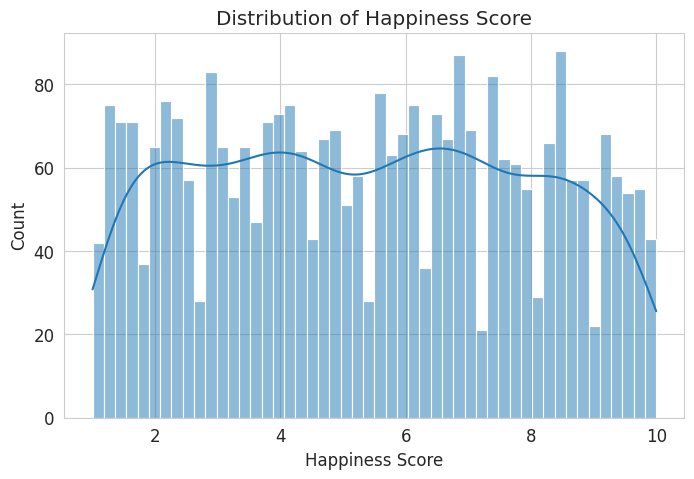

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Happiness Score"], bins=50, kde=True)
plt.title("Distribution of Happiness Score")
plt.xlabel("Happiness Score")
plt.ylabel("Count")
plt.show()

### 3.2 Sleep Hours Distribution

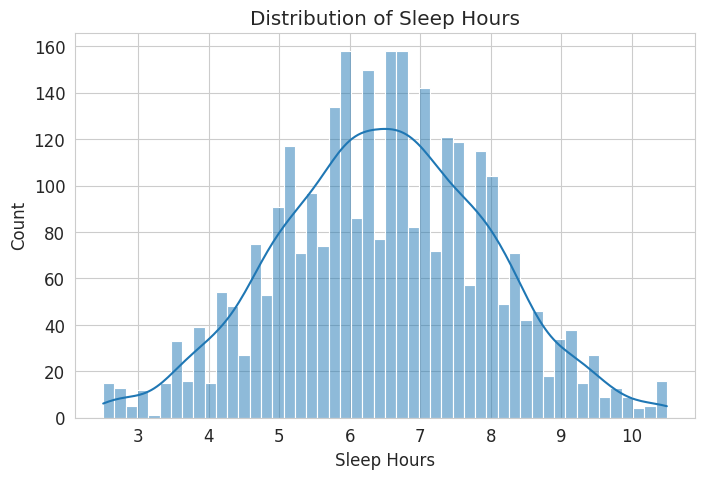

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Sleep Hours"], bins=50, kde=True)
plt.title("Distribution of Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Count")
plt.show()

### 3.3 Screen Time Distribution

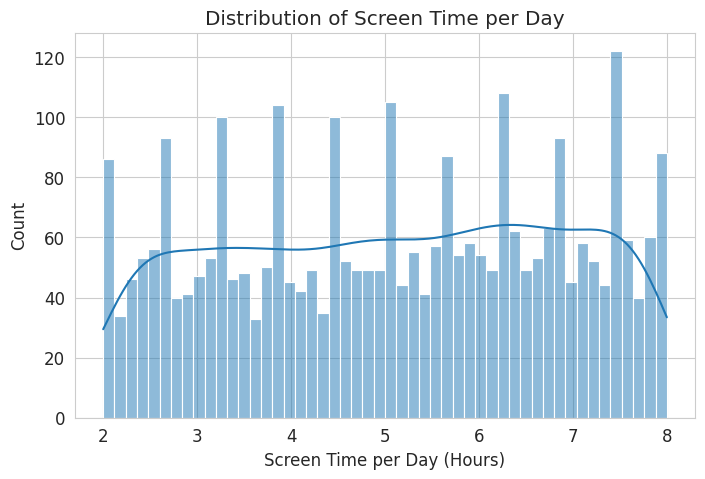

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Screen Time per Day (Hours)"], bins=50, kde=True)
plt.title("Distribution of Screen Time per Day")
plt.xlabel("Screen Time per Day (Hours)")
plt.ylabel("Count")
plt.show()

---
## 4. Group Comparison


### 4.1 Stress Level and Happiness Score

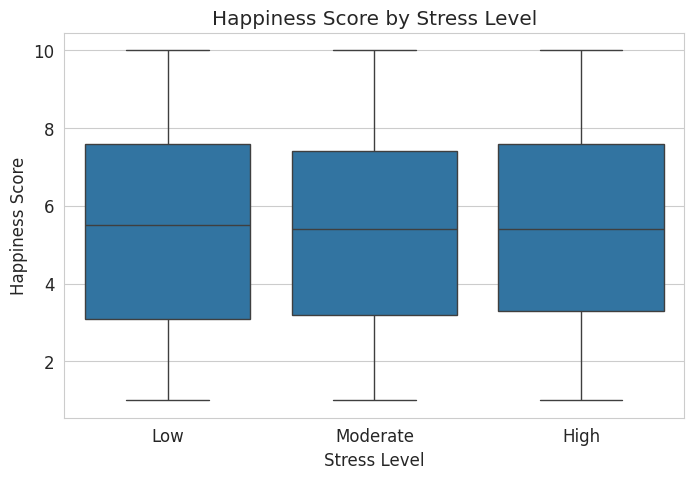

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Stress Level",
    y="Happiness Score",
    order=["Low", "Moderate", "High"]
)
plt.title("Happiness Score by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Happiness Score")
plt.show()

### 4.2 Exercise Level and Happiness Score

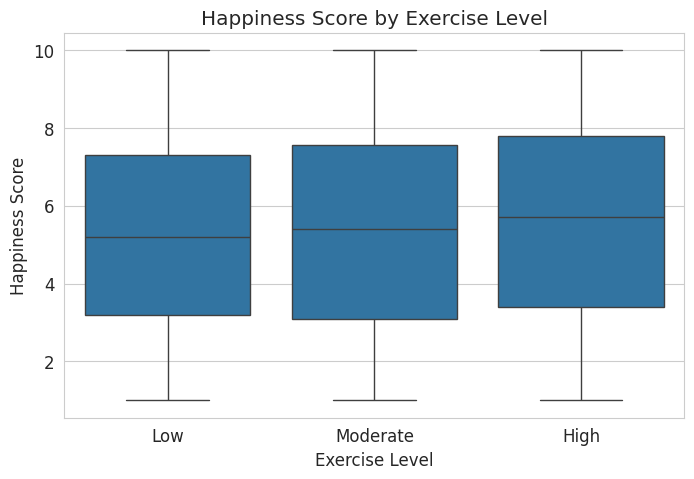

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Exercise Level",
    y="Happiness Score",
    order=["Low", "Moderate", "High"]
)
plt.title("Happiness Score by Exercise Level")
plt.xlabel("Exercise Level")
plt.ylabel("Happiness Score")
plt.show()

### 4.3 Diet Type and Happiness Score

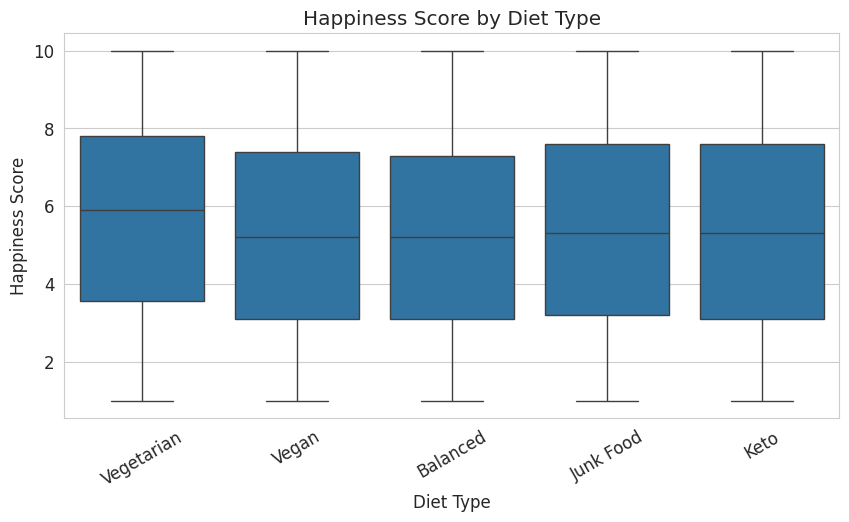

In [34]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="Diet Type",
    y="Happiness Score"
)
plt.title("Happiness Score by Diet Type")
plt.xlabel("Diet Type")
plt.ylabel("Happiness Score")
plt.xticks(rotation=30)
plt.show()

---
## 5. Correlation Analysis

### 5.1 Correlation Heatmap

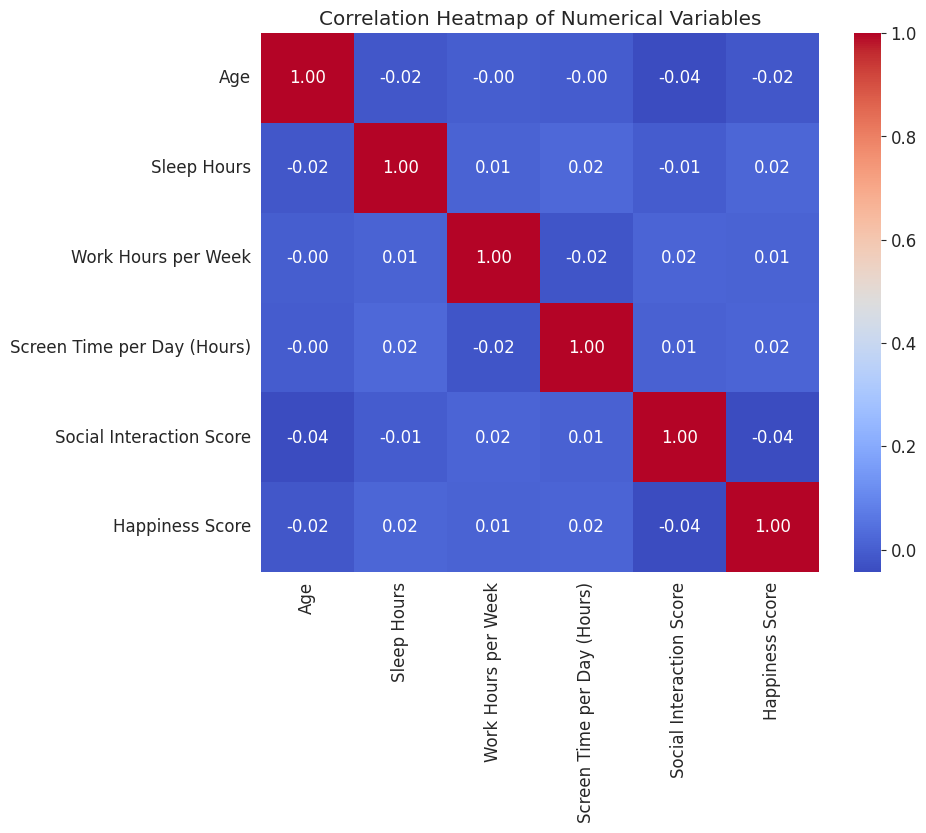

In [35]:
numeric_cols = [
    "Age",
    "Sleep Hours",
    "Work Hours per Week",
    "Screen Time per Day (Hours)",
    "Social Interaction Score",
    "Happiness Score"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

### 5.2 Scatter Plot Analysis

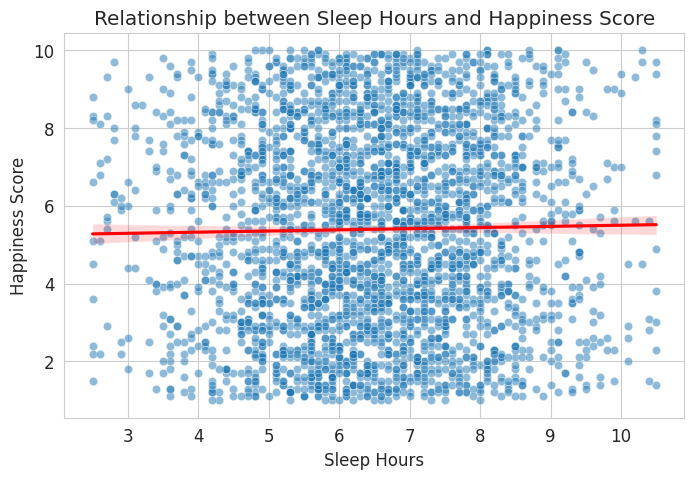

In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Sleep Hours",
    y="Happiness Score",
    alpha=0.5
)
sns.regplot(
    data=df,
    x="Sleep Hours",
    y="Happiness Score",
    scatter=False,
    color="red"
)
plt.title("Relationship between Sleep Hours and Happiness Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Happiness Score")
plt.show()

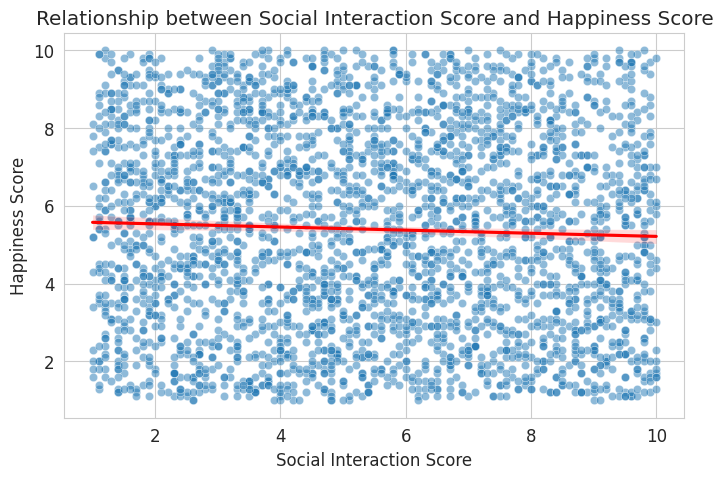

In [37]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Social Interaction Score",
    y="Happiness Score",
    alpha=0.5
)
sns.regplot(
    data=df,
    x="Social Interaction Score",
    y="Happiness Score",
    scatter=False,
    color="red"
)
plt.title("Relationship between Social Interaction Score and Happiness Score")
plt.xlabel("Social Interaction Score")
plt.ylabel("Happiness Score")
plt.show()

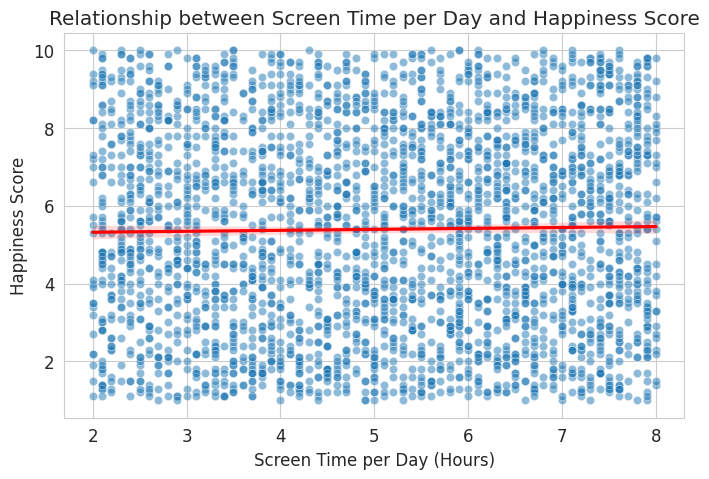

In [38]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Screen Time per Day (Hours)",
    y="Happiness Score",
    alpha=0.5
)

sns.regplot(
    data=df,
    x="Screen Time per Day (Hours)",
    y="Happiness Score",
    scatter=False,
    color="red"
)

plt.title("Relationship between Screen Time per Day and Happiness Score")
plt.xlabel("Screen Time per Day (Hours)")
plt.ylabel("Happiness Score")
plt.show()

---
## 6. EDA Summary

Based on the exploratory data analysis, several key observations can be summarized:

1. The dataset contains 3,000 records and 12 variables after preprocessing.
2. Happiness Score is widely distributed, showing clear variation among participants.
3. Sleep Hours are approximately normally distributed, with most participants sleeping around 6 to 7 hours per day.
4. Boxplots suggest that Exercise Level may have a slight positive relationship with Happiness Score, while Stress Level and Diet Type show less obvious differences.
5. The correlation heatmap shows that numerical lifestyle variables have very weak linear correlations with Happiness Score.
6. These findings suggest that further statistical tests and data mining models are needed to examine group differences and prediction performance.

---
## 7. Statistical Analysis and Modeling

In this section, we implement the proposed statistical analysis and modeling pipeline to investigate factors influencing the **Happiness Score**:
1. **ANOVA** for Categorical Variables (`Exercise Level`, `Stress Level`, `Diet Type`) with assumptions check and post-hoc tests.
2. **Correlation Analysis** (Pearson & Spearman) for Numerical Variables.
3. **Multiple Linear Regression** to evaluate the combined predictive power and identify key predictors, including Multicollinearity check (VIF).

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 載入先前預處理完畢的乾淨原始資料
df = pd.read_csv('cleaned_data.csv')

# 確保類別型欄位的資料型態正確
categorical_cols = ['Exercise Level', 'Stress Level', 'Diet Type']
for col in categorical_cols:
    df[col] = df[col].astype('category')

print(f"Successfully loaded dataset with shape: {df.shape}")

Successfully loaded dataset with shape: (3000, 12)


In [42]:
def run_anova_pipeline(data, group_col, target_col='Happiness Score'):
    print(f"\n{'='*20} ANOVA: {group_col} vs {target_col} {'='*20}")

    # 1. 檢查變異數同質性 (Levene's Test)
    group_names = data[group_col].unique()
    groups = [data[data[group_col] == g][target_col].values for g in group_names]
    levene_stat, p_levene = stats.levene(*groups)
    print(f"Levene's Test for Homogeneity of Variance: Stat={levene_stat:.4f}, p-value={p_levene:.4f}")

    # 2. 執行 ANOVA (根據同質性結果選擇標準 ANOVA 或 Welch's ANOVA)
    formula = f"Q('{target_col}') ~ C(Q('{group_col}'))"

    if p_levene > 0.05:
        print("-> Variances are homogeneous. Running Standard One-way ANOVA...")
        model = ols(formula, data=data).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        p_anova = anova_table['PR(>F)'].iloc[0]
        print(anova_table)
    else:
        print("-> Variances are NOT homogeneous. Running Welch's ANOVA...")
        model = ols(formula, data=data).fit(cov_type='HC3')
        f_test = model.f_test(np.identity(len(model.params))[1:])
        p_anova = float(f_test.pvalue)
        print(f"Welch's ANOVA (Robust F-test) p-value: {p_anova:.4f}")

    # 3. 判斷顯著性並執行事後檢定 (Post-hoc Test)
    if p_anova < 0.05:
        print(f"\n Result is SIGNIFICANT (p = {p_anova:.4f} < 0.05). Rejecting Null Hypothesis.")
        print("Running Tukey's HSD Post-hoc Test...")
        tukey = pairwise_tukeyhsd(endog=data[target_col],
                                  groups=data[group_col],
                                  alpha=0.05)
        print(tukey.summary())
    else:
        print(f"\n Result is NOT SIGNIFICANT (p = {p_anova:.4f} >= 0.05). Fail to reject Null Hypothesis.")
        print(f"Conclusion: There is no significant difference in {target_col} across different {group_col} levels.")

# 依序執行三個類別變數的檢定
for col in categorical_cols:
    run_anova_pipeline(df, col)


==================== ANOVA: Exercise Level vs Happiness Score ====================
Levene's Test for Homogeneity of Variance: Stat=1.6347, p-value=0.1952
-> Variances are homogeneous. Running Standard One-way ANOVA...
                              sum_sq      df         F    PR(>F)
C(Q('Exercise Level'))     34.751865     2.0  2.659272  0.070164
Residual                19582.675122  2997.0       NaN       NaN

 Result is NOT SIGNIFICANT (p = 0.0702 >= 0.05). Fail to reject Null Hypothesis.
Conclusion: There is no significant difference in Happiness Score across different Exercise Level levels.

==================== ANOVA: Stress Level vs Happiness Score ====================
Levene's Test for Homogeneity of Variance: Stat=1.2842, p-value=0.2770
-> Variances are homogeneous. Running Standard One-way ANOVA...
                            sum_sq      df         F    PR(>F)
C(Q('Stress Level'))      5.776426     2.0  0.441369  0.643197
Residual              19611.650561  2997.0       NaN   

In [54]:
numerical_cols = ['Sleep Hours', 'Screen Time per Day (Hours)', 'Work Hours per Week', 'Age', 'Social Interaction Score']
target_col = 'Happiness Score'

print(f"\n{'='*20} Correlation Analysis with Happiness Score {'='*20}")

corr_results = []
for col in numerical_cols:
    # Pearson 相關
    pearson_r, pearson_p = stats.pearsonr(df[col], df[target_col])
    # Spearman 相關
    spearman_r, spearman_p = stats.spearmanr(df[col], df[target_col])

    corr_results.append({
        'Variable': col,
        'Pearson r': pearson_r,
        'Pearson p-val': pearson_p,
        'Spearman r': spearman_r,
        'Spearman p-val': spearman_p
    })

corr_df = pd.DataFrame(corr_results)
# 格式化輸出
print(corr_df.to_string(index=False, formatters={
    'Pearson r': '{:,.4f}'.format, 'Pearson p-val': '{:,.4f}'.format,
    'Spearman r': '{:,.4f}'.format, 'Spearman p-val': '{:,.4f}'.format
}))



==================== Correlation Analysis with Happiness Score ====================
                   Variable Pearson r Pearson p-val Spearman r Spearman p-val
                Sleep Hours    0.0173        0.3429     0.0232         0.2033
Screen Time per Day (Hours)    0.0168        0.3579     0.0175         0.3389
        Work Hours per Week    0.0108        0.5529     0.0110         0.5485
                        Age   -0.0159        0.3851    -0.0166         0.3632
   Social Interaction Score   -0.0402        0.0275    -0.0397         0.0296


In [56]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices  # 修正 VIF 矩陣提取

print(f"\n{'='*20} Multiple Linear Regression Model {'='*20}")

# 1. 定義迴歸公式
formula = "Q('Happiness Score') ~ Q('Sleep Hours') + Q('Screen Time per Day (Hours)') + Q('Work Hours per Week') + Q('Social Interaction Score') + Age + C(Q('Exercise Level')) + C(Q('Stress Level')) + C(Q('Diet Type'))"

# 2. 擬合模型
regression_model = ols(formula, data=df).fit()
print(regression_model.summary())

# 3. 共線性檢查 (VIF, Variance Inflation Factor)
print(f"\n{'='*20} Multicollinearity Check (VIF) {'='*20}")

y, X = dmatrices(formula, data=df, return_type='dataframe')

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
# 計算每個特徵的 VIF
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 顯示結果（排除常數項 Intercept）
print(vif_data[vif_data['Feature'] != 'Intercept'].to_string(index=False, formatters={'VIF': '{:,.2f}'.format}))



==================== Multiple Linear Regression Model ====================
                             OLS Regression Results                             
Dep. Variable:     Q('Happiness Score')   R-squared:                       0.008
Model:                              OLS   Adj. R-squared:                  0.004
Method:                   Least Squares   F-statistic:                     1.890
Date:                  Fri, 05 Jun 2026   Prob (F-statistic):             0.0267
Time:                          18:55:34   Log-Likelihood:                -7061.2
No. Observations:                  3000   AIC:                         1.415e+04
Df Residuals:                      2986   BIC:                         1.423e+04
Df Model:                            13                                         
Covariance Type:              nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
-----------

# Executive Summary of Statistical Analysis and Modeling

This summary evaluates the relationship between various lifestyle habits and the target variable, **Happiness Score**, using a dataset of 3,000 observations. The analysis transitions from univariate group comparisons (ANOVA) to bivariate relationship testing (Correlation) and concludes with an integrated multivariate framework (Multiple Linear Regression).

---

## 1. Categorical Factors vs. Happiness Score (ANOVA)

Three separate One-way Analysis of Variance (ANOVA) tests were performed to determine if categorical lifestyle attributes affect happiness. Homogeneity of variance was verified for all tests using Levene's Test ($p > 0.05$), justifying the use of Standard ANOVA.

### Task 1: Exercise Level vs. Happiness Score
* **Hypotheses**:
    * $H_0$: There is no difference in the mean Happiness Score across different Exercise Levels (Low, Moderate, High).
    * $H_1$: At least one Exercise Level group has a different mean Happiness Score.
* **Experimental Details**: $F(2, 2997) = 2.66$, $p = 0.0702$.
* **Conclusion**: **Fail to reject $H_0$**. At a 5% significance level, variations in exercise habits alone do not yield a statistically significant difference in happiness scores.

### Task 2: Stress Level vs. Happiness Score
* **Hypotheses**:
    * $H_0$: There is no difference in the mean Happiness Score across different Stress Levels (Low, Moderate, High).
    * $H_1$: At least one Stress Level group has a different mean Happiness Score.
* **Experimental Details**: $F(2, 2997) = 0.44$, $p = 0.6432$.
* **Conclusion**: **Fail to reject $H_0$**. Group distributions are statistical equivalents, indicating that standalone stress categories do not differentiate a participant’s happiness level in this sample.

### Task 3: Diet Type vs. Happiness Score
* **Hypotheses**:
    * $H_0$: There is no difference in the mean Happiness Score across different Diet Types.
    * $H_1$: At least one Diet Type group has a different mean Happiness Score.
* **Experimental Details**: $F(4, 2995) = 2.53$, **$p = 0.0386$** (Statistically Significant).
* **Post-hoc Test (Tukey's HSD)**: Out of 10 pairwise comparisons, only **Balanced vs. Vegetarian** was statistically significant ($\text{mean difference} = 0.4168$, $\text{adjusted } p = 0.0362$, $\text{reject} = \text{True}$).
* **Conclusion**: **Reject $H_0$**. Participants adopting a *Vegetarian* diet report a significantly higher mean Happiness Score (by $\approx 0.42$ points) compared to those eating a *Balanced* diet. Other diet pairs show no significant differences.

---

## 2. Bivariate Continuous Relationships (Correlation Analysis)

### Task 4: Numeric Variables vs. Happiness Score
Pearson ($r$) and Spearman ($\rho$) correlation coefficients were computed along with two-tailed significance tests to capture both linear and monotonic relationships between five continuous habits and happiness.

| Variable | Pearson $r$ | Pearson $p$-value | Spearman $\rho$ | Spearman $p$-value | Significance ($p < 0.05$) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Sleep Hours** | 0.0173 | 0.3429 | 0.0232 | 0.2033 | No |
| **Screen Time per Day** | 0.0168 | 0.3579 | 0.0175 | 0.3389 | No |
| **Work Hours per Week** | 0.0108 | 0.5529 | 0.0110 | 0.5485 | No |
| **Age** | -0.0159 | 0.3851 | -0.0166 | 0.3632 | No |
| **Social Interaction Score** | -0.0402 | **0.0275** | -0.0397 | **0.0296** | **Yes (Weak Negative)** |

* **Key Findings**: Physical metrics such as Sleep, Screen Time, Work Hours, and Age demonstrate zero correlation with happiness. However, **Social Interaction Score** yields an unexpected, statistically significant **negative** correlation ($r \approx -0.04, p < 0.05$). Though exceptionally weak, it implies that higher recorded social interactions correspond with slightly lower happiness scores in this sample.
* **Conclusion**: Single numeric lifestyle habits possess virtually no linear predictive power over happiness.

---

## 3. Multivariate Synthesis (Multiple Linear Regression)

### Task 5: Integrated Predictive Model
An Ordinary Least Squares (OLS) regression model was built treating `Happiness Score` as the dependent variable, incorporating all continuous variables and dummy-coded categorical variables simultaneously.

* **Overall Model Fit**:
    * $R\text{-squared} = 0.008$ ($\text{Adjusted } R^2 = 0.004$)
    * $F\text{-statistic}(13, 2986) = 1.890$, $\text{Prob}(F) = \mathbf{0.0267}$
* **Multicollinearity Check (VIF)**: All Variance Inflation Factors (VIF) sit between `1.00` and `1.60`, confirming that no severe multicollinearity exists; the coefficient estimates are stable and reliable.

#### Statistically Significant Predictors ($p < 0.05$):
1.  **`Diet Type [T.Vegetarian]`** ($\beta = 0.4109, p = 0.005$): Holding all other variables constant, being a Vegetarian increases happiness by $0.41$ points relative to a Balanced diet (Baseline).
2.  **`Exercise Level [T.Low]`** ($\beta = -0.2618, p = 0.022$): When controlling for sleep, work, and other attributes, individuals with Low exercise levels experience a significant drop of $-0.26$ points in happiness compared to those with High exercise levels (Baseline).
3.  **`Social Interaction Score`** ($\beta = -0.0424, p = 0.020$): Confirms the bivariate trend; each additional point in social interaction score shaves off $0.04$ points from happiness.

---

# Major Strategic Insights

1.  **The Whole is Different from the Parts**: While `Exercise Level` did not show group-level differences in isolation (ANOVA, $p=0.07$), its critical impact emerged during regression modeling ($p=0.022$). Once other confounding variables (like work hours and sleep) are held constant, having **Low Exercise** is revealed to be a significant detriment to happiness.
2.  **The Vegetarian Advantage**: `Diet Type [Vegetarian]` proved to be the most resilient and powerful positive predictor across both ANOVA and Regression frameworks, consistently maintaining a $\approx 0.41$ positive delta over a balanced diet.
3.  **The "Social Fatigue" Paradox**: The statistically significant negative trajectory of `Social Interaction Score` poses a compelling paradox, suggesting that higher social quantities might diminish quality of life within this context.
4.  **Limits of Linear Lifestyle Tracking**: The overall model yields an $R^2$ of $0.8\%$. This indicates that while the combinations of tracked daily habits are statistically connected to well-being ($Prob(F) < 0.05$), they leave $99.2\%$ of the variance unexplained. Human happiness is profoundly intricate and likely guided by unobserved traits (e.g., genetics, financials, or deep psychological factors) rather than basic behavioral tallies.

##